In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 1338
Number of columns: 7


In [5]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [10]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
print("Number of duplicated rows:")
print(df.duplicated().sum())

Number of duplicated rows:
1


In [12]:
df = df.drop_duplicates()
print("Rows after removing duplicates:",len(df))

Rows after removing duplicates: 1337


In [13]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [14]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
df["children"] = pd.to_numeric(df["children"], errors="coerce")
df["charges"] = pd.to_numeric(df["charges"], errors="coerce")

print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [15]:
numeric_columns = ["age", "bmi" ,"children","charges"]
print(numeric_columns)

['age', 'bmi', 'children', 'charges']


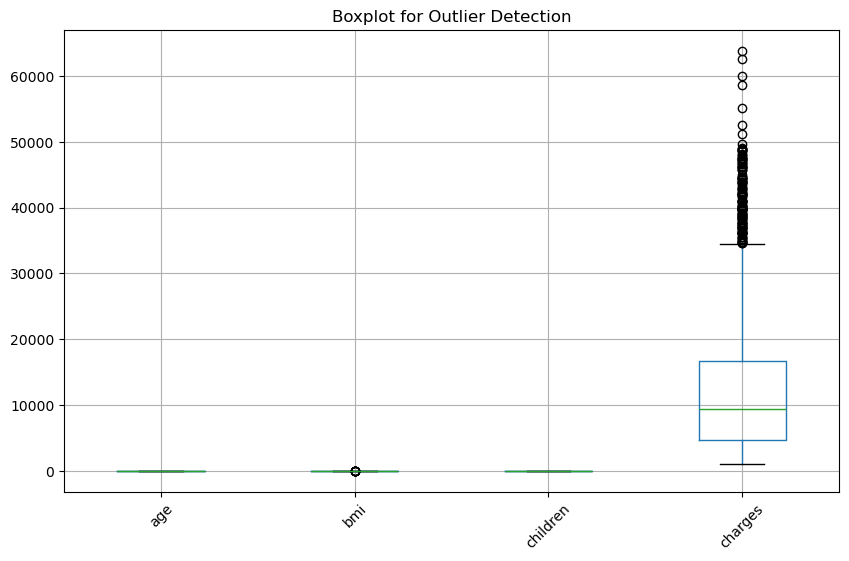

In [16]:
plt.figure(figsize=(10, 6))
df[numeric_columns].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [17]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower_bound,
        upper_bound
    )

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


In [18]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower_bound,
        upper_bound
    )

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


In [19]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column, "remaining outliers:", len(outliers))

age remaining outliers: 0
bmi remaining outliers: 0
children remaining outliers: 0
charges remaining outliers: 0


In [20]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Child", "Young Adult", "Adult", "Middle Age", "Senior"]
)

In [21]:
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,Young Adult,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,Child,Obese
2,28,male,33.000,3,no,southeast,4449.46200,Young Adult,Obese
3,33,male,22.705,0,no,northwest,21984.47061,Adult,Normal
4,32,male,28.880,0,no,northwest,3866.85520,Adult,Overweight


In [23]:
categorical_columns = [
    "sex",
    "smoker",
    "region",
    "age_group",
    "bmi_category"
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [24]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_group_Young Adult,age_group_Adult,age_group_Middle Age,age_group_Senior,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,27.900,0,16884.92400,False,True,False,False,True,True,False,False,False,False,True,False
1,18,33.770,1,1725.55230,True,False,False,True,False,False,False,False,False,False,False,True
2,28,33.000,3,4449.46200,True,False,False,True,False,True,False,False,False,False,False,True
3,33,22.705,0,21984.47061,True,False,True,False,False,False,True,False,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False,False,True,False,False,False,True,False


In [25]:
print("Final dataset shape:", df_encoded.shape)

Final dataset shape: (1337, 16)


In [26]:
print("Missing values:")
print(df_encoded.isnull().sum().sum())

Missing values:
0


In [27]:
print("Duplicate rows:", df_encoded.duplicated().sum())

Duplicate rows: 0


In [28]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      1337 non-null   int64  
 1   bmi                      1337 non-null   float64
 2   children                 1337 non-null   int64  
 3   charges                  1337 non-null   float64
 4   sex_male                 1337 non-null   bool   
 5   smoker_yes               1337 non-null   bool   
 6   region_northwest         1337 non-null   bool   
 7   region_southeast         1337 non-null   bool   
 8   region_southwest         1337 non-null   bool   
 9   age_group_Young Adult    1337 non-null   bool   
 10  age_group_Adult          1337 non-null   bool   
 11  age_group_Middle Age     1337 non-null   bool   
 12  age_group_Senior         1337 non-null   bool   
 13  bmi_category_Normal      1337 non-null   bool   
 14  bmi_category_Overweight  1337

In [29]:
df_encoded.to_csv(
    "insurance_cleaned.csv",
    index=False
)
print("cleaned dataset saved successfully.")

cleaned dataset saved successfully.


# Insurance Dataset – Data Preprocessing Documentation

## 1. Data Source
The insurance dataset was collected from Kaggle.

## 2. Dataset Size
The dataset contains more than 1000 samples and satisfies the internship requirement.

## 3. Data Cleaning
- Checked for missing values.
- Missing numerical values were handled using the median.
- Missing categorical values were handled using the mode.
- Duplicate records were identified and removed.
- Data types were checked and converted where required.

## 4. Outlier Handling
Outliers in numerical columns were detected using the Interquartile Range (IQR) method.
Extreme values were handled using IQR-based capping.

## 5. Feature Engineering
Two new features were created:
- Age Group
- BMI Category

## 6. Categorical Encoding
Categorical features were converted into numerical features using one-hot encoding.

## 7. Final Output
The processed dataset was saved as:

insurance_cleaned.csv

## 8. Preprocessing Pipeline
Data Collection
→ Data Inspection
→ Missing Value Handling
→ Duplicate Removal
→ Data Type Conversion
→ Outlier Detection and Handling
→ Feature Engineering
→ Categorical Encoding
→ Final Validation
→ Clean Dataset